<p style="font-size: 22px; font-weight: bold; margin: 0;">
  Alpaycan CABBAR / 40507357 - Group B
</p>
<p style="font-size: 22px; font-weight: bold; margin: 0 0 24px 0;">
  DSA8040 – Foundations of Data Analytics and Artificial Intelligence - Assignment 2
</p>

<h1 style="text-align: center; margin-top: 0; font-size: 40px; font-weight: bold; margin-top: 0;">
  Predictive Analysis Under Distribution Shift
</h1>


### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## 1. Initial Exploratory Data Analysis (EDA) 

### 1.1 Loading the data and basic checks
I uploaded the Wine training dataset, the Clean test dataset, the Group B shifted test dataset, and the corresponding labels. Since I am in Group B, I use `X_test_shifted_B.csv` as the shifted evaluation set. Before training any models, I first checked the basic structure of the files. This follows the purpose of EDA: to understand the data, check for errors or missing values, and identify patterns before modelling.

In [2]:
RANDOM_STATE = 42

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

X_test_clean = pd.read_csv("X_test_clean.csv")
X_test_shifted = pd.read_csv("X_test_shifted_B.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

datasets = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test_clean": X_test_clean,
    "X_test_shifted_B": X_test_shifted,
    "y_test": y_test
}

summary_rows = []

for name, data in datasets.items():
    if isinstance(data, pd.Series):
        rows = data.shape[0]
        columns = 1
        missing_values = data.isna().sum()
        duplicate_rows = data.duplicated().sum()
    else:
        rows, columns = data.shape
        missing_values = data.isna().sum().sum()
        duplicate_rows = data.duplicated().sum()
        
    summary_rows.append({
        "dataset": name,
        "rows": rows,
        "columns": columns,
        "missing_values": missing_values,
        "duplicate_rows": duplicate_rows
    })

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary

,dataset,rows,columns,missing_values,duplicate_rows
0,X_train,142,13,0,0
1,y_train,142,1,0,139
2,X_test_clean,36,13,0,0
3,X_test_shifted_B,36,13,0,0
4,y_test,36,1,0,33


In [3]:
print("Clean test columns match training:", list(X_train.columns) == list(X_test_clean.columns))
print("Shifted B test columns match training:", list(X_train.columns) == list(X_test_shifted.columns))

feature_columns = pd.DataFrame({
    "feature_name": X_train.columns
})
feature_columns

Clean test columns match training: True
Shifted B test columns match training: True


,feature_name
0,alcohol
1,malic_acid
2,ash
3,alcalinity_of_ash
4,magnesium
5,total_phenols
6,flavanoids
7,nonflavanoid_phenols
8,proanthocyanins
9,color_intensity


The basic dataset checks show that the feature datasets loaded correctly. `X_train` has 142 observations and 13 feature columns, while both `X_test_clean` and `X_test_shifted_B` have 36 observations and the same 13 feature columns. This means that the Clean and Shifted B test sets can be tested with the same trained models.

I don't need to use missing-value imputation because none of the uploaded files have missing values. The duplicate rows for `y_train` and `y_test` are not a problem because these files have class labels. Since there are only three possible classes, repeated label values are expected. The important thing is that the feature datasets don't have duplicate rows.

I also made sure that the Clean test and Shifted B test feature columns match the training feature columns. The two checks came back `True`, which means that all models will use the same input representation for both training and testing. The 13 features are continuous measurements of wine chemistry, such as `alcohol`, `malic_acid`, `flavanoids`, `color_intensity`, `hue` and `proline`.

### 1.2 Class balance
Next, I checked the class balance in the training and test labels. This is important because if one class was much larger than the others, accuracy alone could be misleading. Since this is a three-class classification task, I wanted to see whether Classes 0, 1, and 2 were represented in similar proportions.

In [35]:
class_balance = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index()
})

class_balance["train_percent"] = 100 * class_balance["train_count"] / len(y_train)
class_balance["test_percent"] = 100 * class_balance["test_count"] / len(y_test)

class_balance.round(2)

,train_count,test_count,train_percent,test_percent
target,,,,
0,47,12,33.10,33.33
1,57,14,40.14,38.89
2,38,10,26.76,27.78


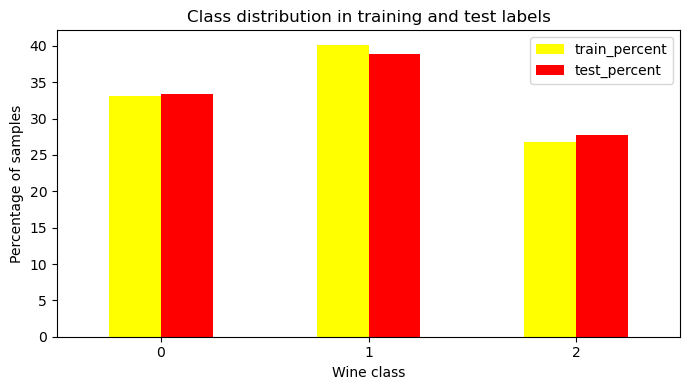

In [49]:
class_balance[["train_percent", "test_percent"]].plot(kind="bar", figsize=(7, 4), color=["yellow", "red"])

plt.title("Class distribution in training and test labels")
plt.xlabel("Wine class")
plt.ylabel("Percentage of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The class balance table shows that the training and test sets have very similar class proportions. In the training set, Class 0 is about 33.1%, Class 1 is about 40.1%, and Class 2 is about 26.8%. In the test set, Class 0 is about 33.3%, Class 1 is about 38.9%, and Class 2 is about 27.8%.

This means that the test labels are spread out in a way that is very similar to how the training labels are spread out. Therefore, if model performance changes between the Clean and Shifted B test sets, it is unlikely to be caused by a major change in class balance. The more important issue is the feature distribution shift identified later in the EDA.

### 1.3 Identifying the Group B shift
Then I directly compared the Clean test set with the Group B shifted test set. Since both test sets use the same labels, I focused on which input features changed. This helps identify whether the difference between Clean and Shifted B is caused by a broad change across all variables or by a targeted shift in specific features.

In [50]:
feature_change = pd.DataFrame(index=X_train.columns)

feature_change["mean_abs_difference"] = (
    X_test_shifted - X_test_clean
).abs().mean()

feature_change["max_abs_difference"] = (
    X_test_shifted - X_test_clean
).abs().max()

feature_change["changed_rows"] = (
    (X_test_shifted - X_test_clean).abs() > 1e-10
).sum()

feature_change = feature_change.sort_values(
    "mean_abs_difference",
    ascending=False
)

feature_change.round(3)

,mean_abs_difference,max_abs_difference,changed_rows
color_intensity,2.173,6.828,36
alcohol,0.919,1.694,36
proanthocyanins,0.544,1.632,36
hue,0.253,0.601,36
nonflavanoid_phenols,0.147,0.360,36
magnesium,0.000,0.000,0
alcalinity_of_ash,0.000,0.000,0
ash,0.000,0.000,0
malic_acid,0.000,0.000,0
total_phenols,0.000,0.000,0


In [51]:
changed_features = feature_change[
    feature_change["changed_rows"] > 0
].index.tolist()

changed_features_table = pd.DataFrame({
    "changed_feature": changed_features
})

changed_features_table

,changed_feature
0,color_intensity
1,alcohol
2,proanthocyanins
3,hue
4,nonflavanoid_phenols


The direct Clean vs Shifted B comparison shows that the Group B shift affects only five of the thirteen input features. These are `color_intensity`, `alcohol`, `proanthocyanins`, `hue` and `nonflavanoid_phenols`. All 36 test rows changed for each of these features.

The biggest average change is in `color_intensity`, which has an average absolute difference of about 2.17 and a maximum difference of about 6.83. The next largest changes are in `alcohol` and `proanthocyanins`. The remaining eight features have zero difference between the Clean and Shifted B test sets. This means that the Group B shifted dataset is not a completely different dataset. Instead, it is a targeted covariate shift where only selected input variables have been altered while the labels remain unchanged.

### 1.4 Visualising the shifted features
To visualise the shift, I plotted the training, Clean test, and Shifted B test distributions for the changed features. I used boxplots because they clearly show the median, spread, and extreme values of each feature.

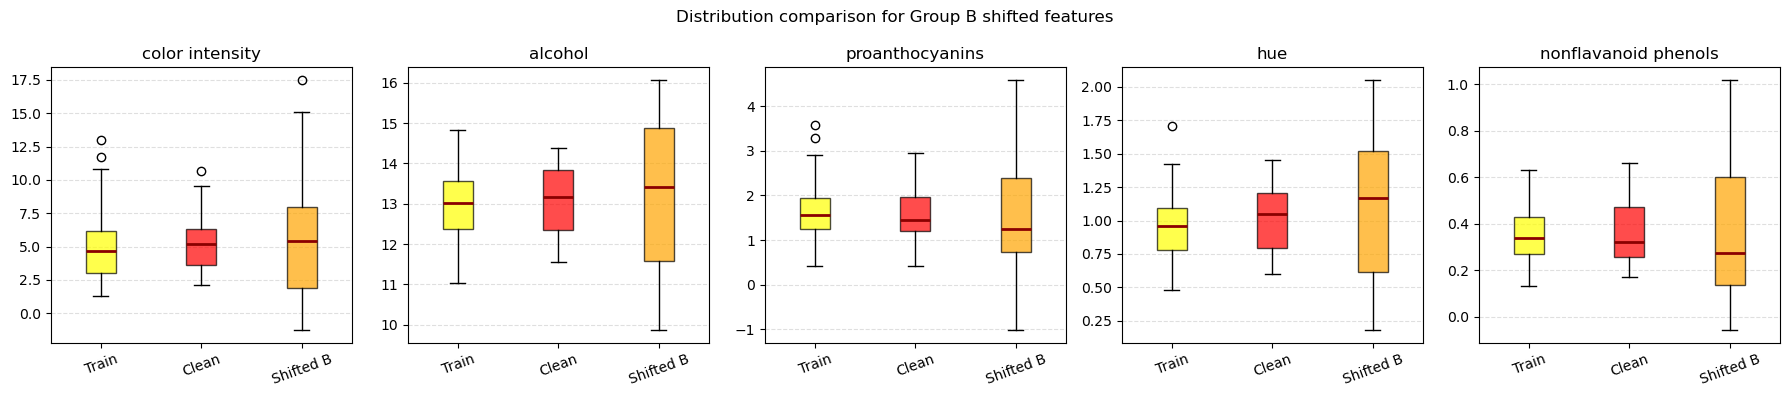

In [52]:
colors = ["yellow", "red", "orange"]

fig, axes = plt.subplots(1, len(changed_features), figsize=(18, 4))

for ax, feature in zip(axes, changed_features):
    bp = ax.boxplot(
        [X_train[feature], X_test_clean[feature], X_test_shifted[feature]],
        tick_labels=["Train", "Clean", "Shifted B"],
        patch_artist=True
    )

    for box, color in zip(bp["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)

    for median in bp["medians"]:
        median.set_color("darkred")
        median.set_linewidth(2)

    ax.set_title(feature.replace("_", " "))
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribution comparison for Group B shifted features")
plt.tight_layout()
plt.show()

The boxplots show that the Shifted B distributions are generally wider than the Clean test distributions for the five changed features. This is especially visible for `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`, where the Shifted B boxes and whiskers cover a larger range.

Some shifted values are also more extreme than the values seen in the training and Clean test sets. For example, `color_intensity` has a much wider shifted range and includes a high outlier, while `proanthocyanins` and `nonflavanoid_phenols` include unusually low shifted values. This supports the idea that Group B introduces a feature-level distribution shift rather than simply adding small random noise.

### 1.5 Out-of-training-range analysis
Finally, I counted how many Clean and Shifted B test values fall outside the training range for each feature. This is important because models are trained only on the training distribution. If shifted test values move beyond the range seen during training, the model may need to make predictions in unfamiliar regions of the feature space.

In [53]:
out_of_range_rows = []

for feature in X_train.columns:
    train_min = X_train[feature].min()
    train_max = X_train[feature].max()
    
    clean_outside = (
        (X_test_clean[feature] < train_min) |
        (X_test_clean[feature] > train_max)
    ).sum()
    
    shifted_outside = (
        (X_test_shifted[feature] < train_min) |
        (X_test_shifted[feature] > train_max)
    ).sum()
    
    out_of_range_rows.append({
        "feature": feature,
        "clean_outside_train_range": clean_outside,
        "shifted_outside_train_range": shifted_outside
    })

out_of_range = pd.DataFrame(out_of_range_rows)
out_of_range = out_of_range.sort_values(
    "shifted_outside_train_range",
    ascending=False
)

out_of_range

,feature,clean_outside_train_range,shifted_outside_train_range
7,nonflavanoid_phenols,1,17
0,alcohol,0,15
9,color_intensity,0,14
8,proanthocyanins,1,10
10,hue,0,7
6,flavanoids,3,3
12,proline,2,2
11,od280/od315_of_diluted_wines,1,1
2,ash,1,1
4,magnesium,0,0


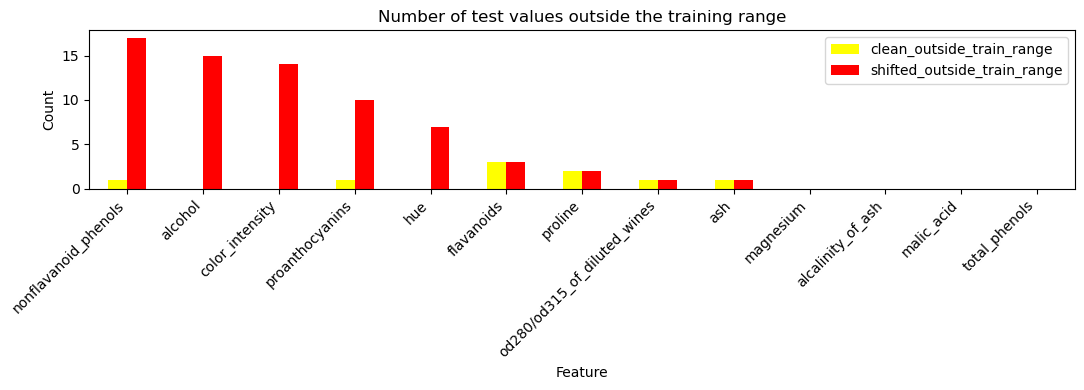

In [54]:
out_of_range.set_index("feature")[[
    "clean_outside_train_range",
    "shifted_outside_train_range"
]].plot(kind="bar", figsize=(11, 4), color=["yellow", "red"])

plt.title("Number of test values outside the training range")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The out-of-training-range analysis shows that the Shifted B test set contains many more values outside the training range than the Clean test set. This is strongest for the same features identified earlier as shifted. In particular, `nonflavanoid_phenols` has 17 shifted values outside the training range, `alcohol` has 15, `color_intensity` has 14, `proanthocyanins` has 10, and `hue` has 7.

In comparison, the Clean test set has very few outside-range values for these features. This supports the idea that the Group B shift moves several samples into regions of the feature space that the models did not see during training. This is important for the later modelling sections because models are trained only on `X_train`. If the shifted test set contains values outside the training range, the models may become less reliable because they are being asked to generalise beyond the distribution they learned from.

### 1.6 EDA summary
Overall, the first EDA shows that the uploaded datasets are clean and consistent. There are no missing values in the feature datasets, the training and test feature columns match, and the Clean and Shifted B test sets can both be evaluated with the same `y_test` labels.  The class balance is also similar between the training and test labels. The training set contains about 33.1% Class 0, 40.1% Class 1 and 26.8% Class 2, while the test set contains about 33.3% Class 0, 38.9% Class 1, and 27.8% Class 2. This means the main issue is not a major label imbalance.

The EDA's main finding is that the Group B shifted test set changes only five input features: `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`. The `color_intensity` feature has the biggest average change, followed by `alcohol` and `proanthocyanins`. The boxplots also show that the shifted versions of these features are generally more spread out and have more extreme values.

The out-of-training-range analysis supports this further. The Shifted B test set has many more values outside the training range, especially for `nonflavanoid_phenols`, `alcohol`, `color_intensity`, `proanthocyanins` and `hue`. This suggests a targeted covariate shift, where the input distribution changes while the labels remain unchanged. This EDA gives the basis for the modelling analysis. If model performance drops on the Shifted B test set, I can relate that drop to the shifted feature distributions and the fact that several shifted samples move into regions of the feature space that were rare or unseen during training.

## 2. Model Assumptions and Inductive Bias

In this assignment, I use four models: Logistic Regression, Gaussian Naïve Bayes, Support Vector Machine, and Random Forest. I chose these models because they represent different modelling assumptions and different inductive biases. This is useful because the aim of the assignment is not only to compare accuracy, but also to understand how different models generalise when the test distribution changes.

From my initial EDA, I found that the Group B shifted test set mainly changes five input features: `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`. The labels remain unchanged, so this appears to be a covariate shift: the input feature distribution changes while the target labels remain the same. Because each model relies on different assumptions, I expect them to respond differently to this shift.

### Logistic Regression

Logistic Regression is a straightforward linear model that presupposes a linear amalgamation of the input features can depict the correlation between them and the class log-odds. Consequently, the decision boundaries are linear within the feature space. 

The main benefit of Logistic Regression is that it is easy to understand, stable, and simple. But because it is so simple, it can't learn decision boundaries that are too complicated. If the actual differentiation between wine classes is nonlinear, Logistic Regression may not provide an adequate fit.

I employ feature scaling for Logistic Regression due to the input variables being assessed on varying scales. Under the Group B shift, I expect Logistic Regression to be moderately sensitive. If shifted feature values move samples across the learned linear decision boundaries, the model may misclassify them. However, because the model is relatively simple, it may also be less sensitive to small amounts of noise than more flexible models.

### Gaussian Naïve Bayes

Gaussian Naïve Bayes is a probabilistic generative model. It assumes that each feature follows a Gaussian distribution within each class. It also assumes that features are conditionally independent given the class label.

This is a strong assumption because real chemical features in the Wine dataset may be correlated. Therefore, the model’s assumptions may not fully match the data. Its decision boundaries can be nonlinear, but they are still restricted by the Gaussian and independence assumptions.

I expect Gaussian Naïve Bayes to be sensitive to the Group B shift if the shifted feature values become unlikely under the class-specific Gaussian distributions learned from the training data. Since the EDA showed that some shifted features become more extreme and fall outside the training range, Naïve Bayes may assign unreliable probabilities to some shifted samples.

### Support Vector Machine

The Support Vector Machine is a margin-based classifier. It tries to find a decision boundary that separates classes with a large margin. I use an RBF kernel so that the model can represent nonlinear decision boundaries.

The main inductive bias of the SVM is that good generalisation comes from a stable large-margin boundary. With the RBF kernel, the model can learn more complex boundaries than Logistic Regression. However, this also means it depends strongly on distances and geometry in the feature space, so feature scaling is important.

Under the Group B shift, I expect the SVM to be sensitive if shifted samples move away from the regions seen during training. Since the shifted features change the geometry of the data, some samples may move closer to the wrong class region or across the learned margin.

### Random Forest

Random Forest is a type of ensemble model that uses trees. It makes a lot of decision trees and combines their predictions. Each tree makes decisions by splitting the feature space using threshold rules.

The main inductive bias of Random Forest is that it can use a set of feature-based rules to separate the data. It can also model nonlinear relationships and interactions between features, which means it can show more complicated decision boundaries than Logistic Regression. Additionally, it is usually more stable than a single decision tree because averaging many trees lowers variance.

Random Forest is not affected by feature scaling in the same way that Logistic Regression or SVM is. This is because it uses threshold-based splits instead of distance-based calculations. But Random Forests don't work well outside of the training range. If the Shifted B test set has feature values that are more extreme than those seen during training, the model might put those samples in leaf regions that don't fit them well. I think Random Forest can deal with some noise, but it will still be weak when the distribution shift moves feature values outside of the training range.

### Summary

Overall, these four models give a useful comparison of different inductive biases. Logistic Regression represents a simple linear model, Gaussian Naïve Bayes represents a probabilistic model with strong distributional assumptions, SVM represents a margin-based nonlinear model, and Random Forest represents a nonlinear tree-based ensemble.

| Model | Main assumption / inductive bias | Decision boundary complexity | Expected sensitivity to Group B shift |
|---|---|---|---|
| Logistic Regression | Class log-odds are a linear function of the features | Linear | Moderate sensitivity if shifted values cross linear boundaries |
| Gaussian Naïve Bayes | Features are Gaussian and conditionally independent within each class | Simple to moderately nonlinear | High sensitivity if shifted values are unlikely under learned class distributions |
| SVM with RBF kernel | Good generalisation comes from large-margin separation in feature space | Nonlinear and flexible | Sensitive to scaling and shifted feature geometry |
| Random Forest | Classes can be separated by many feature-threshold rules | Nonlinear and flexible | Robust to some noise, but weaker when shifted values fall outside training ranges |

These assumptions will help me interpret the results in the next sections. If a model performs well on the Clean test set but drops on the Shifted B test set, I will relate that behaviour back to the assumptions described here.

## 3. Model Implementation and Classification Metrics

### 3.1 Model setup
In this part, I use the four models from Section 2: Logistic Regression, Gaussian Naïve Bayes, Support Vector Machine, and Random Forest. I use the same `X_train` and `y_train` data to train all of the models, and then I test them on both the Clean test set and the Group B shifted test set.

I use the provided test sets only for evaluation, not for training or tuning. This is important because the assignment focuses on generalisation under distribution shift, so the Clean and Shifted B test sets should remain unseen evaluation data.

I use `StandardScaler` for Logistic Regression and SVM because these models are affected by feature scale. I don't scale Random Forest or Gaussian Naïve Bayes because tree-based models use thresholds to split features, so it doesn't matter to them. Gaussian Naïve Bayes can also work with the original continuous feature values.

In [55]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    
    "Gaussian Naive Bayes": GaussianNB(),
    
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

model_setup = pd.DataFrame({
    "model": list(models.keys()),
    "preprocessing": [
        "StandardScaler",
        "None",
        "StandardScaler",
        "None"
    ],
    "main_settings": [
        "LogisticRegression(max_iter=5000, random_state=42)",
        "GaussianNB()",
        "SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)",
        "RandomForestClassifier(n_estimators=200, random_state=42)"
    ]
})

model_setup

,model,preprocessing,main_settings
0,Logistic Regression,StandardScaler,"LogisticRegression(max_iter=5000, random_state..."
1,Gaussian Naive Bayes,None,GaussianNB()
2,SVM RBF,StandardScaler,"SVC(kernel='rbf', C=1.0, gamma='scale', random..."
3,Random Forest,None,"RandomForestClassifier(n_estimators=200, rando..."


I used simple and reasonable model settings rather than extensive hyperparameter tuning. Logistic Regression uses a higher `max_iter` value to ensure convergence, SVM uses an RBF kernel with default `C` and `gamma`, and Random Forest uses 200 trees with a fixed random seed for reproducibility. This matches the aim of the assignment: comparing how different modelling assumptions behave under distribution shift, rather than trying to find a perfectly optimised model.

### 3.2 Training and evaluation
I trained each model on the training set only. I then used the trained models to predict labels for both the Clean test set and the Group B shifted test set, using the same `y_test` labels for evaluation.

This allows me to compare normal held-out performance with performance under distribution shift. The results from this step are stored and used in the following subsections to compare accuracy, class-wise metrics, and confusion matrices.

In [56]:
results = {}
accuracy_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_clean = model.predict(X_test_clean)
    y_pred_shifted = model.predict(X_test_shifted)
    
    clean_accuracy = accuracy_score(y_test, y_pred_clean)
    shifted_accuracy = accuracy_score(y_test, y_pred_shifted)
    
    results[model_name] = {
        "model": model,
        "y_pred_clean": y_pred_clean,
        "y_pred_shifted": y_pred_shifted,
        "clean_accuracy": clean_accuracy,
        "shifted_accuracy": shifted_accuracy
    }
    
    accuracy_rows.append({
        "model": model_name,
        "clean_accuracy": clean_accuracy,
        "shifted_B_accuracy": shifted_accuracy,
        "accuracy_drop": clean_accuracy - shifted_accuracy
    })

accuracy_results = pd.DataFrame(accuracy_rows)

print(f"Finished training and evaluating {len(models)} models.")

Finished training and evaluating 4 models.


### 3.3 Accuracy comparison on Clean and Shifted B test sets
The table below compares each model’s accuracy on the Clean test set and the Group B shifted test set. The accuracy drop is calculated as:

`Clean accuracy - Shifted B accuracy`

A larger drop means the model is less robust to the shifted input distribution.

In [57]:
accuracy_results_sorted = accuracy_results.sort_values(
    "shifted_B_accuracy",
    ascending=False
)

accuracy_results_sorted.round(3)

,model,clean_accuracy,shifted_B_accuracy,accuracy_drop
0,Logistic Regression,0.972,0.972,0.000
1,Gaussian Naive Bayes,0.972,0.972,0.000
3,Random Forest,1.000,0.944,0.056
2,SVM RBF,0.972,0.833,0.139


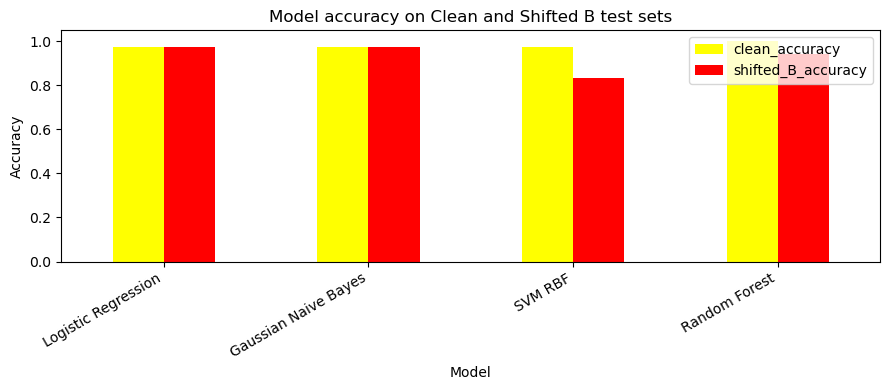

In [71]:
accuracy_plot = accuracy_results.set_index("model")[["clean_accuracy","shifted_B_accuracy"]]

accuracy_plot.plot(kind="bar", figsize=(9, 4), color=["yellow", "red"])

plt.title("Model accuracy on Clean and Shifted B test sets")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The accuracy comparison shows that all four models perform strongly on the Clean test set. Random Forest has the highest Clean accuracy at 1.000, while Logistic Regression, Gaussian Naïve Bayes, and SVM RBF each achieve 0.972.

The Shifted B results show a clearer difference in robustness. Logistic Regression and Gaussian Naïve Bayes do not lose accuracy, remaining at 0.972 on both Clean and Shifted B. Random Forest drops from 1.000 to 0.944, which is a small decrease. SVM RBF shows the largest decline, dropping from 0.972 to 0.833.

This means that the change in the Group B distribution affects the models in different ways. The SVM RBF model seems to be the most sensitive to the changed feature distribution, while the Logistic Regression and Gaussian Naïve Bayes models are the most stable when it comes to overall accuracy.

### 3.4 Class-wise metrics
Accuracy gives an overall score, but it does not show which classes are being misclassified. Therefore, I calculated precision, recall, and F1-score for each class on both the Clean and Shifted B test sets. This helps identify whether the distribution shift affects all classes equally or mainly damages performance for specific wine classes.

In [72]:
class_metric_rows = []

for model_name, result in results.items():
    for dataset_name, predictions in [
        ("Clean", result["y_pred_clean"]),
        ("Shifted B", result["y_pred_shifted"])
    ]:
        report = classification_report(
            y_test,
            predictions,
            output_dict=True,
            zero_division=0
        )
        
        for class_label in sorted(y_test.unique()):
            class_report = report[str(class_label)]
            
            class_metric_rows.append({
                "model": model_name,
                "dataset": dataset_name,
                "class": class_label,
                "precision": class_report["precision"],
                "recall": class_report["recall"],
                "f1_score": class_report["f1-score"],
                "support": class_report["support"]
            })

class_metrics = pd.DataFrame(class_metric_rows)

In [73]:
class_metrics_rounded = class_metrics.copy()

for col in ["precision", "recall", "f1_score"]:
    class_metrics_rounded[col] = class_metrics_rounded[col].round(3)

class_metrics_display = class_metrics_rounded.copy()
class_metrics_display = class_metrics_display.rename(columns={
    "f1_score": "f1-score"
})

class_metrics_display

,model,dataset,class,precision,recall,f1-score,support
0,Logistic Regression,Clean,0,1.000,1.000,1.000,12.0
1,Logistic Regression,Clean,1,0.933,1.000,0.966,14.0
2,Logistic Regression,Clean,2,1.000,0.900,0.947,10.0
3,Logistic Regression,Shifted B,0,1.000,0.917,0.957,12.0
4,Logistic Regression,Shifted B,1,0.933,1.000,0.966,14.0
5,Logistic Regression,Shifted B,2,1.000,1.000,1.000,10.0
6,Gaussian Naive Bayes,Clean,0,0.923,1.000,0.960,12.0
7,Gaussian Naive Bayes,Clean,1,1.000,0.929,0.963,14.0
8,Gaussian Naive Bayes,Clean,2,1.000,1.000,1.000,10.0
9,Gaussian Naive Bayes,Shifted B,0,1.000,0.917,0.957,12.0


The class-wise metrics show that most models do well on all three classes on the Clean test set. The Clean test F1-scores for Logistic Regression, Gaussian Naïve Bayes, and SVM RBF are all high, and Random Forest gets perfect class-wise scores on the Clean test set.

The Shifted B metrics show that there is more variation between models. Overall, Logistic Regression and Gaussian Naïve Bayes stay the same. Random Forest still does well, but its F1-score goes down a little for all classes. The SVM RBF shows the most clear drop, especially for Class 0 and Class 1. The recall for Class 0 drops to 0.667 on the Shifted B set, and the precision for Class 1 drops to 0.700. This means that the shifted data makes these classes harder to understand.

In [74]:
class_name_map = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2"
}

f1_clean = class_metrics[class_metrics["dataset"] == "Clean"].pivot(
    index="model",
    columns="class",
    values="f1_score"
).rename(columns=class_name_map)

f1_shifted = class_metrics[class_metrics["dataset"] == "Shifted B"].pivot(
    index="model",
    columns="class",
    values="f1_score"
).rename(columns=class_name_map)

f1_drop = f1_clean - f1_shifted
f1_drop = f1_drop.round(3)

f1_drop.columns.name = None
f1_drop.index.name = "Model"

f1_drop

,Class 0,Class 1,Class 2
Model,,,
Gaussian Naive Bayes,0.003,-0.003,0.000
Logistic Regression,0.043,0.000,-0.053
Random Forest,0.043,0.067,0.053
SVM RBF,0.200,0.142,0.058


The F1-score drop table summarises how much class-wise performance is lost from Clean to Shifted B. Gaussian Naïve Bayes is almost unchanged, with F1 drops close to zero for all classes. Logistic Regression has a small drop for Class 0, while Class 2 slightly improves on the shifted set.

Random Forest has small F1 drops across all three classes, showing that it remains fairly robust but is still affected by the shift. SVM RBF has the largest F1 drops, especially for Class 0 with a drop of 0.200 and Class 1 with a drop of 0.142. This supports the earlier accuracy result that SVM RBF is the least robust model under the Group B shift.

### 3.5 Confusion matrix inspection
I inspected confusion matrices for all four models on both the Clean and Shifted B test sets. Accuracy shows the overall performance, but confusion matrices show which classes are confused with each other. This is useful because the assignment asks not only for overall metrics, but also for class-wise behaviour under distribution shift.

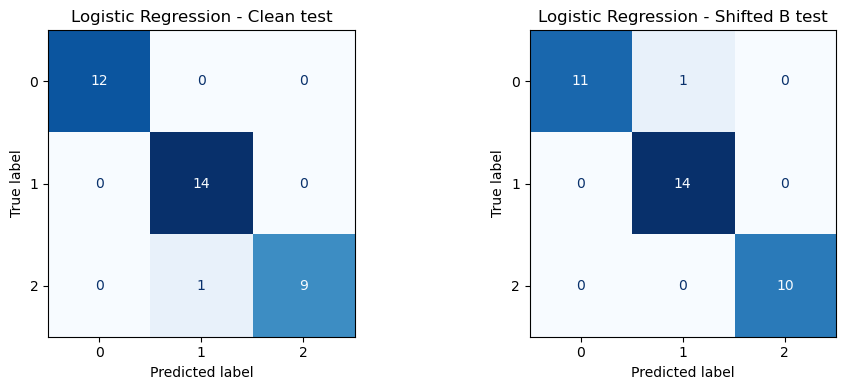

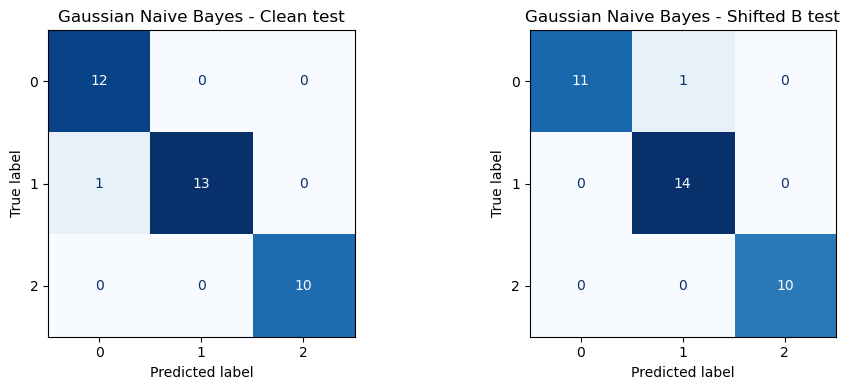

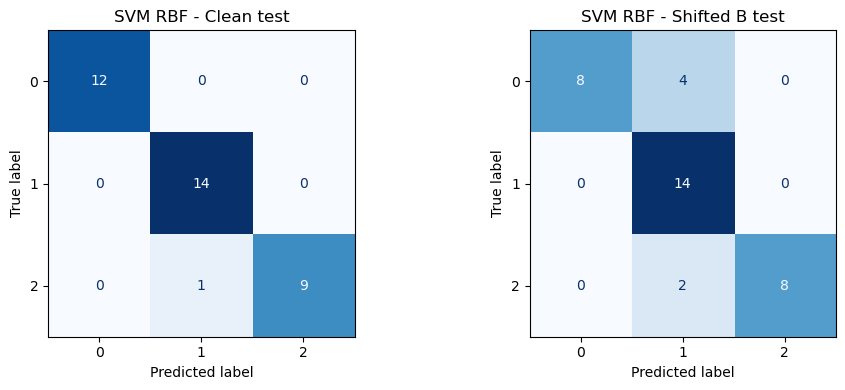

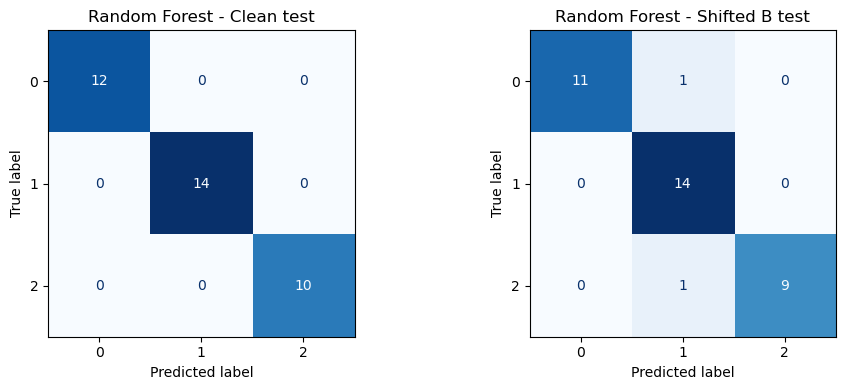

In [75]:
class_labels = sorted(y_test.unique())

for model_name, result in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        result["y_pred_clean"],
        labels=class_labels,
        ax=axes[0],
        cmap="Blues",
        colorbar=False
    )
    axes[0].set_title(f"{model_name} - Clean test")
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        result["y_pred_shifted"],
        labels=class_labels,
        ax=axes[1],
        cmap="Blues",
        colorbar=False
    )
    axes[1].set_title(f"{model_name} - Shifted B test")
    
    plt.tight_layout()
    plt.show()

The confusion matrices show that most models make very few mistakes on the Clean test set. Logistic Regression, Gaussian Naïve Bayes, and SVM RBF each make only one Clean test error, while Random Forest correctly classifies all Clean test samples.

The Shifted B confusion matrices show that the error patterns change under distribution shift. Logistic Regression and Gaussian Naïve Bayes remain very stable, each making only one shifted-test error. Random Forest makes two shifted-test errors: one Class 0 sample is predicted as Class 1, and one Class 2 sample is predicted as Class 1.

The largest change is for SVM RBF. On the Shifted B test set, four true Class 0 samples are predicted as Class 1, and two true Class 2 samples are also predicted as Class 1. This means SVM RBF increasingly over-predicts Class 1 under the Group B shift. This supports the earlier finding that SVM RBF is the least robust model in this comparison.

### 3.6 Clean vs Shifted B performance summary
I summarised the main classification results by comparing overall accuracy, accuracy drop, and class-wise F1-score drop. This helps identify which model generalised most reliably from the Clean test set to the Group B shifted test set.

In [76]:
def models_at(column, value):
    return ", ".join(accuracy_results.loc[accuracy_results[column] == value, "model"])

summary_findings = pd.DataFrame([
    ["Best Clean test accuracy", models_at("clean_accuracy", accuracy_results["clean_accuracy"].max()), accuracy_results["clean_accuracy"].max()],
    ["Best Shifted B test accuracy", models_at("shifted_B_accuracy", accuracy_results["shifted_B_accuracy"].max()), accuracy_results["shifted_B_accuracy"].max()],
    ["Smallest accuracy drop", models_at("accuracy_drop", accuracy_results["accuracy_drop"].min()), accuracy_results["accuracy_drop"].min()],
    ["Largest accuracy drop", models_at("accuracy_drop", accuracy_results["accuracy_drop"].max()), accuracy_results["accuracy_drop"].max()]
], columns=["criterion", "model", "value"])

summary_findings["value"] = summary_findings["value"].round(3)
summary_findings

,criterion,model,value
0,Best Clean test accuracy,Random Forest,1.000
1,Best Shifted B test accuracy,"Logistic Regression, Gaussian Naive Bayes",0.972
2,Smallest accuracy drop,"Logistic Regression, Gaussian Naive Bayes",0.000
3,Largest accuracy drop,SVM RBF,0.139


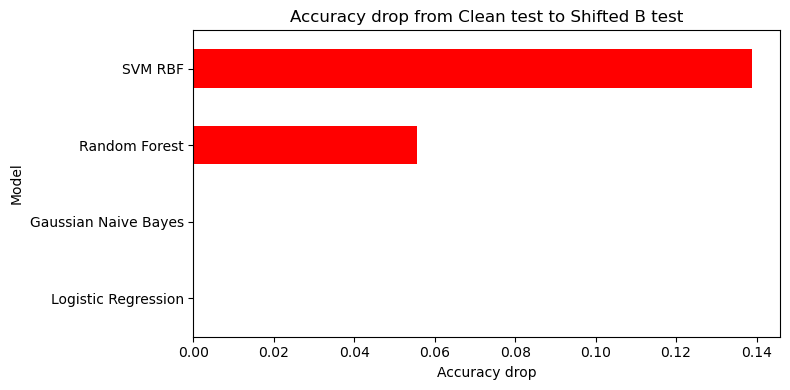

In [84]:
accuracy_results.set_index("model")["accuracy_drop"].sort_values().plot(kind="barh", figsize=(8, 4), color=["red"])

plt.title("Accuracy drop from Clean test to Shifted B test")
plt.xlabel("Accuracy drop")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

The summary confirms that Random Forest achieved the highest Clean test accuracy, with a score of 1.000. However, the best model on the Shifted B test set was Logistic Regression, tied in practice with Gaussian Naïve Bayes, both reaching 0.972.

The accuracy-drop plot shows the robustness pattern more clearly. Logistic Regression and Gaussian Naïve Bayes have no accuracy drop between the Clean and Shifted B test sets. The drop for Random Forest is only 0.056, while the drop for SVM RBF is the biggest at 0.139.

This suggests that the model with the best Clean test performance is not necessarily the most robust under distribution shift. SVM RBF is the least robust model in this section, while Logistic Regression and Gaussian Naïve Bayes generalise most consistently across the two evaluation sets.

These accuracy results, class-wise metrics, and confusion matrices provide the basis for the failure-mode analysis in Section 4, where I examine why the shifted feature values may have caused class-specific errors.

## 4. Failure Modes and Robustness

### 4.1 Robustness overview
In Section 3, I reported the Clean and Shifted B accuracy for each model. Here, I use those results to analyse robustness rather than just repeating the same performance table.

From the EDA, I found that the Group B shifted set mainly changes `color_intensity`, `alcohol`, `proanthocyanins`, `hue` and `nonflavanoid_phenols`. These changes create a covariate shift because the input features change while the labels remain the same. To compare robustness, I find both the absolute and relative accuracy drops from Clean to Shifted B.

In [86]:
robustness_analysis = accuracy_results.copy()

robustness_analysis["relative_accuracy_drop"] = (
    robustness_analysis["accuracy_drop"] / robustness_analysis["clean_accuracy"]
)

robustness_analysis["clean_accuracy"] = robustness_analysis["clean_accuracy"].round(3)
robustness_analysis["shifted_B_accuracy"] = robustness_analysis["shifted_B_accuracy"].round(3)
robustness_analysis["accuracy_drop"] = robustness_analysis["accuracy_drop"].round(3)
robustness_analysis["relative_accuracy_drop"] = robustness_analysis["relative_accuracy_drop"].round(3)

robustness_analysis = robustness_analysis.sort_values(
    "relative_accuracy_drop",
    ascending=False
)

robustness_analysis

,model,clean_accuracy,shifted_B_accuracy,accuracy_drop,relative_accuracy_drop
2,SVM RBF,0.972,0.833,0.139,0.143
3,Random Forest,1.000,0.944,0.056,0.056
1,Gaussian Naive Bayes,0.972,0.972,0.000,0.000
0,Logistic Regression,0.972,0.972,0.000,0.000


The robustness table shows that SVM RBF is the least robust model under the Group B shift. Its accuracy drops from 0.972 on the Clean test set to 0.833 on the Shifted B test set, giving an absolute drop of 0.139 and a relative drop of 0.143.

Random Forest also loses some performance, but not as much: from 1.000 to 0.944, which is a drop of 0.056. Logistic Regression and Gaussian Naïve Bayes do not show any drop in accuracy in this test; both test sets stay at 0.972. 

This suggests that the Group B shift does not affect all models in the same way. The SVM RBF model is the most sensitive to changes in the feature distribution, while Logistic Regression and Gaussian Naïve Bayes are the most stable when it comes to overall accuracy.

### 4.2 Class-wise degradation under distribution shift
Overall accuracy does not show which wine classes are most affected by the Group B shift. To analyse this, I compared class-wise recall and F1-score between the Clean and Shifted B test sets. Recall is useful because it shows how many true samples of each class were correctly recognised. F1-score is also useful because it combines precision and recall into one class-wise score.

In [87]:
recall_clean = class_metrics[class_metrics["dataset"] == "Clean"].pivot(
    index="model",
    columns="class",
    values="recall"
)

recall_shifted = class_metrics[class_metrics["dataset"] == "Shifted B"].pivot(
    index="model",
    columns="class",
    values="recall"
)

recall_drop = recall_clean - recall_shifted
recall_drop = recall_drop.round(3)

recall_drop.columns.name = None
recall_drop.index.name = "Model"

recall_drop = recall_drop.rename(columns={
    0: "Class 0",
    1: "Class 1",
    2: "Class 2"
})

display(Markdown("#### Recall drop by model and class"))
display(recall_drop)

#### Recall drop by model and class

,Class 0,Class 1,Class 2
Model,,,
Gaussian Naive Bayes,0.083,-0.071,0.0
Logistic Regression,0.083,0.000,-0.1
Random Forest,0.083,0.000,0.1
SVM RBF,0.333,0.000,0.1


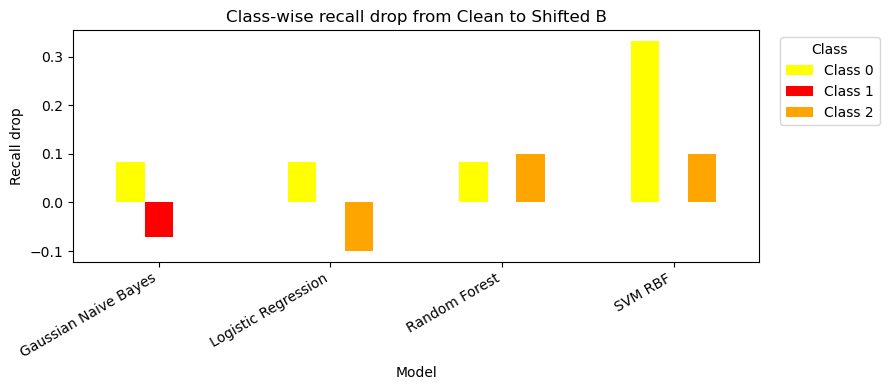

In [97]:
ax = recall_drop.plot(kind="bar",figsize=(9, 4), color=["yellow","red","orange"])

plt.title("Class-wise recall drop from Clean to Shifted B")
plt.xlabel("Model")
plt.ylabel("Recall drop")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [98]:
f1_clean = class_metrics[class_metrics["dataset"] == "Clean"].pivot(
    index="model",
    columns="class",
    values="f1_score"
)

f1_shifted = class_metrics[class_metrics["dataset"] == "Shifted B"].pivot(
    index="model",
    columns="class",
    values="f1_score"
)

f1_drop = f1_clean - f1_shifted
f1_drop = f1_drop.round(3)

f1_drop.columns.name = None
f1_drop.index.name = "Model"

f1_drop = f1_drop.rename(columns={
    0: "Class 0",
    1: "Class 1",
    2: "Class 2"
})

display(Markdown("#### F1-score drop by model and class"))
display(f1_drop)

#### F1-score drop by model and class

,Class 0,Class 1,Class 2
Model,,,
Gaussian Naive Bayes,0.003,-0.003,0.000
Logistic Regression,0.043,0.000,-0.053
Random Forest,0.043,0.067,0.053
SVM RBF,0.200,0.142,0.058


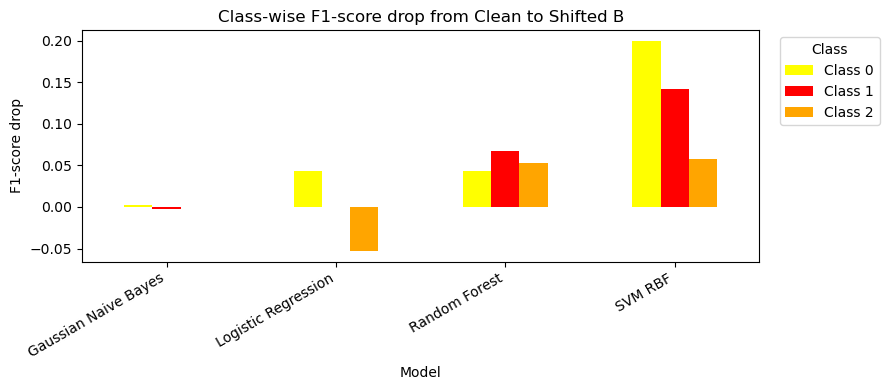

In [99]:
ax = f1_drop.plot(kind="bar", figsize=(9, 4), color=["yellow","red","orange"])

plt.title("Class-wise F1-score drop from Clean to Shifted B")
plt.xlabel("Model")
plt.ylabel("F1-score drop")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The recall-drop table and plot show that the largest recall degradation occurs for SVM RBF on Class 0, where recall drops by 0.333. This means SVM RBF becomes much worse at recognising true Class 0 wines under the Group B shift. SVM RBF and Random Forest also lose some recall for Class 2, with drops of 0.100.

There are also some negative drops, like Gaussian Naïve Bayes for Class 1 and Logistic Regression for Class 2. A negative value means that the model did a little better for that class on the Shifted B set than on the Clean set. These small improvements are possible because the test set is small and the shift doesn't affect every class in the same way.

The F1-score drop gives a broader view because it combines precision and recall. The largest F1 drops are again for SVM RBF, especially Class 0 with a drop of 0.200 and Class 1 with a drop of 0.142. Random Forest shows smaller F1 drops across all classes. Logistic Regression and Gaussian Naïve Bayes are much more stable, with F1 drops close to zero for most classes.

In general, this shows that the Group B shift causes degradation that is specific to each class, not all classes equally. The main failure pattern is mostly in SVM RBF, especially for Class 0 and Class 1.

### 4.3 How the error patterns changed

After checking class-wise degradation, I compared how the actual error patterns changed between the Clean and Shifted B test sets. Instead of only looking at accuracy, I examined the confusion matrices in a more quantitative way. This helps show whether the Group B shift created extra mistakes and which class confusions became more common.

In [102]:
error_pattern_rows = []
class_labels = sorted(y_test.unique())

for model_name, result in results.items():
    for dataset_name, predictions in [
        ("Clean", result["y_pred_clean"]),
        ("Shifted B", result["y_pred_shifted"])
    ]:
        cm = confusion_matrix(y_test, predictions, labels=class_labels)
        
        total_samples = cm.sum()
        correct_predictions = np.trace(cm)
        total_errors = total_samples - correct_predictions
        
        off_diagonal = cm.copy()
        np.fill_diagonal(off_diagonal, 0)
        
        max_error_count = off_diagonal.max()
        
        if max_error_count > 0:
            actual_idx, predicted_idx = np.unravel_index(
                off_diagonal.argmax(),
                off_diagonal.shape
            )
            main_confusion = f"Actual {class_labels[actual_idx]} → Predicted {class_labels[predicted_idx]}"
        else:
            main_confusion = "No errors"
        
        error_pattern_rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "correct_predictions": correct_predictions,
            "total_errors": total_errors,
            "main_confusion": main_confusion,
            "main_confusion_count": max_error_count
        })

error_patterns = pd.DataFrame(error_pattern_rows)
error_patterns

,model,dataset,correct_predictions,total_errors,main_confusion,main_confusion_count
0,Logistic Regression,Clean,35,1,Actual 2 → Predicted 1,1
1,Logistic Regression,Shifted B,35,1,Actual 0 → Predicted 1,1
2,Gaussian Naive Bayes,Clean,35,1,Actual 1 → Predicted 0,1
3,Gaussian Naive Bayes,Shifted B,35,1,Actual 0 → Predicted 1,1
4,SVM RBF,Clean,35,1,Actual 2 → Predicted 1,1
5,SVM RBF,Shifted B,30,6,Actual 0 → Predicted 1,4
6,Random Forest,Clean,36,0,No errors,0
7,Random Forest,Shifted B,34,2,Actual 0 → Predicted 1,1


The error-pattern table shows that Logistic Regression and Gaussian Naïve Bayes remain stable, with one error on both the Clean and Shifted B test sets. The Clean test set has no errors with Random Forest, but the Shifted B test set has two errors.

The biggest change is for SVM RBF. It makes only one error on the Clean test set, but six errors on the Shifted B test set. Its main shifted-set confusion is `Actual 0 → Predicted 1`, which occurs four times. This suggests that the Group B shift causes SVM RBF to confuse several true Class 0 wines with Class 1.

In [103]:
clean_errors = error_patterns[error_patterns["dataset"] == "Clean"][
    ["model", "total_errors"]
].rename(columns={"total_errors": "clean_errors"})

shifted_errors = error_patterns[error_patterns["dataset"] == "Shifted B"][
    ["model", "total_errors"]
].rename(columns={"total_errors": "shifted_B_errors"})

error_change = pd.merge(clean_errors, shifted_errors, on="model")
error_change["extra_errors_under_shift"] = (
    error_change["shifted_B_errors"] - error_change["clean_errors"]
)

error_change = error_change.sort_values(
    "extra_errors_under_shift",
    ascending=False
)

error_change

,model,clean_errors,shifted_B_errors,extra_errors_under_shift
2,SVM RBF,1,6,5
3,Random Forest,0,2,2
1,Gaussian Naive Bayes,1,1,0
0,Logistic Regression,1,1,0


The error-change table shows that the Group B shift had the biggest effect on the SVM RBF model. It makes five additional errors on the Shifted B test set compared with the Clean test set. Random Forest makes two additional errors, while Logistic Regression and Gaussian Naïve Bayes make no additional errors.

This supports the earlier robustness results: SVM RBF is the least robust model in this comparison, while Logistic Regression and Gaussian Naïve Bayes are the most stable in terms of total error count.

In [104]:
representative_model = error_change.iloc[0]["model"]
representative_model

'SVM RBF'

Since SVM RBF has the largest increase in errors under the Group B shift, I use it as the representative model for the detailed confusion-matrix difference analysis.

In [105]:
clean_cm = confusion_matrix(
    y_test,
    results[representative_model]["y_pred_clean"],
    labels=class_labels
)

shifted_cm = confusion_matrix(
    y_test,
    results[representative_model]["y_pred_shifted"],
    labels=class_labels
)

cm_difference = shifted_cm - clean_cm

cm_difference_table = pd.DataFrame(
    cm_difference,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

cm_difference_table

,Predicted 0,Predicted 1,Predicted 2
Actual 0,-4,4,0
Actual 1,0,0,0
Actual 2,0,1,-1


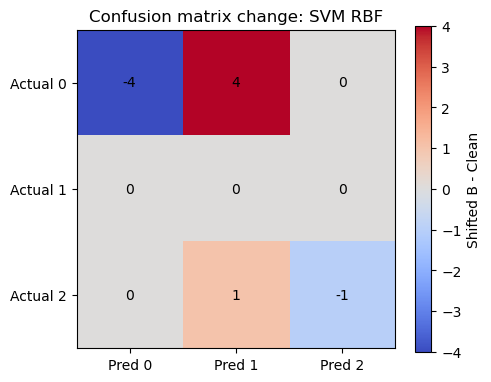

In [106]:
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm_difference, cmap="coolwarm")

ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels([f"Pred {label}" for label in class_labels])
ax.set_yticklabels([f"Actual {label}" for label in class_labels])

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j, i, cm_difference[i, j], ha="center", va="center")

plt.title(f"Confusion matrix change: {representative_model}")
plt.colorbar(im, label="Shifted B - Clean")
plt.tight_layout()
plt.show()

The confusion-matrix difference table is calculated as:

`Shifted B confusion matrix - Clean confusion matrix`

In SVM RBF, the main change is in true Class 0. The model loses four correct Class 0 predictions, which is shown by `-4` in the `Actual 0, Predicted 0` cell. These four samples are then incorrectly classified as Class 1, which is shown by `+4` in the `Actual 0, Predicted 1` cell.

There is also a smaller change for Class 2. SVM RBF loses one correct Class 2 prediction and gains one additional `Actual 2 → Predicted 1` error. This means that SVM RBF is more likely to predict Class 1 for samples that really belong to Class 0 or Class 2 when the Group B shift is on.


### 4.4 Linking errors back to the shifted features

I learned in the EDA section that the Group B shift mostly changed five things: `color_intensity`, `alcohol`, `proanthocyanins`, `hue` and `nonflavanoid_phenols`. To connect this shift to model failure, I analysed the Shifted B predictions for the representative model selected in the previous subsection, which was SVM RBF.

The aim is to check whether the misclassified Shifted B samples have more extreme shifted-feature values or more values outside the training range than the correctly classified samples.

In [107]:
failure_analysis = X_test_shifted.copy()

failure_analysis["actual_class"] = y_test.values
failure_analysis["predicted_class"] = results[representative_model]["y_pred_shifted"]
failure_analysis["correct_prediction"] = (
    failure_analysis["actual_class"] == failure_analysis["predicted_class"]
)

failure_analysis[["actual_class", "predicted_class", "correct_prediction"]].head()

,actual_class,predicted_class,correct_prediction
0,0,1,False
1,2,2,True
2,0,0,True
3,1,1,True
4,1,1,True


In [108]:
prediction_counts = failure_analysis["correct_prediction"].value_counts().rename(index={
    True: "Correct",
    False: "Incorrect"
})

prediction_counts

correct_prediction
Correct      30
Incorrect     6
Name: count, dtype: int64

For SVM RBF on the Shifted B test set, 30 samples were classified correctly and 6 samples were misclassified. I use these two groups to compare whether the shifted feature values are different for correct and incorrect predictions.

In [109]:
changed_feature_summary = failure_analysis.groupby("correct_prediction")[changed_features].mean()

changed_feature_summary.index = changed_feature_summary.index.map({
    True: "Correct predictions",
    False: "Incorrect predictions"
})

changed_feature_summary = changed_feature_summary.round(3)
changed_feature_summary

,color_intensity,alcohol,proanthocyanins,hue,nonflavanoid_phenols
correct_prediction,,,,,
Incorrect predictions,8.294,14.769,2.062,1.146,0.257
Correct predictions,5.222,12.992,1.386,1.020,0.403


The changed-feature summary shows that the incorrectly classified samples have higher average values for several shifted features. For example, the incorrect group has a much higher average `color_intensity` value, 8.294 compared with 5.222 for correctly classified samples. It also has higher average `alcohol`, 14.769 compared with 12.992, and higher average `proanthocyanins`, 2.062 compared with 1.386.

This suggests that SVM RBF struggles particularly when the shifted samples have larger values in the features affected by the Group B shift. The difference is less clear for `nonflavanoid_phenols`, where the incorrect group has a lower average than the correct group. Therefore, the failure is not caused by every shifted feature in the same way, but the pattern suggests that extreme shifted values in some features are linked to the SVM errors.

In [110]:
for feature in changed_features:
    train_min = X_train[feature].min()
    train_max = X_train[feature].max()
    
    failure_analysis[f"{feature}_outside_train_range"] = (
        (failure_analysis[feature] < train_min) |
        (failure_analysis[feature] > train_max)
    )

outside_columns = [f"{feature}_outside_train_range" for feature in changed_features]

failure_analysis["num_shifted_features_outside_train_range"] = (
    failure_analysis[outside_columns].sum(axis=1)
)

outside_range_summary = failure_analysis.groupby("correct_prediction")[
    "num_shifted_features_outside_train_range"
].agg(["mean", "median", "max", "count"])

outside_range_summary.index = outside_range_summary.index.map({
    True: "Correct predictions",
    False: "Incorrect predictions"
})

outside_range_summary.round(3)

,mean,median,max,count
correct_prediction,,,,
Incorrect predictions,2.0,2.0,4,6
Correct predictions,1.7,2.0,3,30


This is also supported by the summary for samples that were not in the training range. Samples that were not correctly classified had an average of 2.0 shifted features outside the training range, while samples that were correctly classified had an average of 1.7. The median is 2.0 for both groups, but the maximum is higher for incorrect predictions, reaching 4 outside-range shifted features.

This suggests that the SVM RBF errors are partly due to samples that move further away from the training distribution. The difference isn't big, but it fits with what the EDA found: the Group B shift makes more values that are too high or too low for the affected features.

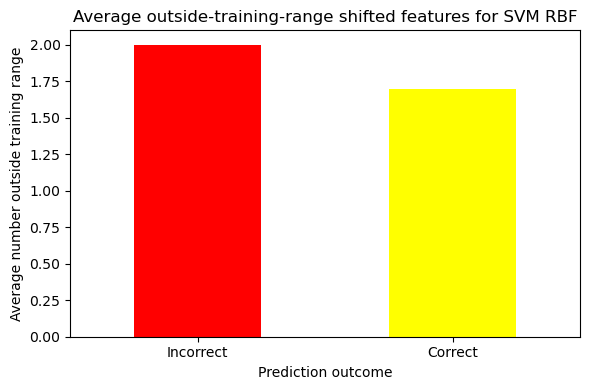

In [120]:
outside_summary_plot = failure_analysis.groupby("correct_prediction")["num_shifted_features_outside_train_range"].mean()

outside_summary_plot.index = ["Incorrect", "Correct"]

outside_summary_plot.plot(kind="bar", figsize=(6, 4), color=["red","yellow"])

plt.title(f"Average outside-training-range shifted features for {representative_model}")
plt.xlabel("Prediction outcome")
plt.ylabel("Average number outside training range")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart shows that misclassified samples have a slightly higher average number of shifted features outside the training range: 2.0 compared with 1.7 for correctly classified samples. The table also shows that the incorrect group has a higher maximum value, with one sample having four outside-range shifted features.

This suggests that out-of-range shifted values contribute to the SVM RBF errors, but they are not the only factor. The final prediction also depends on how these shifted values interact with the learned decision boundary.

### 4.5 Model-specific failure-mode interpretation

The Group B shift did not affect all models equally. This is expected because each model has a different inductive bias. The EDA showed that the shift mainly changed `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`, with many shifted values moving outside the training range.

#### Logistic Regression

Logistic Regression was very reliable. Its accuracy stayed at 0.972 on both the Clean and Shifted B test sets. This means that the changed feature values didn't move many samples far enough across the learned linear decision boundaries to change the final predictions.

However, the class-wise metrics still changed slightly. Class 0 F1-score dropped a little, while Class 2 improved slightly. This shows that stable overall accuracy can still hide small class-wise changes.

#### Gaussian Naïve Bayes

Gaussian Naïve Bayes was also stable, with accuracy staying at 0.972 on both test sets. This is noteworthy because the model relies on strong assumptions: it assumes that features are Gaussian within each class and conditionally independent.

In this case, the Group B shift didn't hurt those assumptions very much. The F1-score changes were almost zero across the classes, so Naïve Bayes was still reliable for this specific shifted dataset.

#### Support Vector Machine

SVM RBF was the least robust model. Its accuracy dropped from 0.972 on the Clean test set to 0.833 on the Shifted B test set. The main issue was Class 0, where recall dropped by 0.333 and F1-score dropped by 0.200.

The confusion matrices showed that four true Class 0 samples were misclassified as Class 1. This fits the SVM inductive bias because the RBF kernel depends on distances and geometry in the scaled feature space. The shifted features appear to move some samples closer to the Class 1 region, causing systematic misclassification.

#### Random Forest

Random Forest performed best on the Clean test set, with accuracy of 1.000, but dropped to 0.944 on the Shifted B test set. This shows that it was strong but not completely unaffected by the shift.

Its errors were limited: one true Class 0 and one true Class 2 sample were predicted as Class 1. This fits with the Random Forest inductive bias. It can model nonlinear feature interactions, but it splits based on thresholds and doesn't smoothly extrapolate when values that have been shifted go outside of the training range.

#### Comparison across methodologies

Overall, the failure pattern was systematic rather than random. Logistic Regression and Gaussian Naïve Bayes were the most stable in overall accuracy. Random Forest was strong but showed a small drop. SVM RBF was the least robust because the shifted features changed the feature-space geometry that its RBF kernel relies on.

This shows why evaluating models only on Clean test data is not enough. A model may perform well on standard held-out data but fail when the input distribution changes in a way that violates its assumptions.

### 4.6 Robustness findings and transition to synthesis

The failure-mode analysis shows that the Group B shift affected the models in different ways. The shift was not random across all variables. From the EDA, it mainly changed `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`. Because these are input features used by the classifiers, the shift changed the feature space that the models were evaluated on.

The overall robustness results show that Logistic Regression and Gaussian Naïve Bayes were the most stable, with no accuracy drop between the Clean and Shifted B test sets. The accuracy of Random Forest went down slightly, from 1.000 to 0.944. SVM RBF was the least robust model, dropping from 0.972 to 0.833.

The class-wise recall and F1-score drops show that degradation was not equal across all classes. The clearest failure was SVM RBF on Class 0, where recall dropped by 0.333 and F1-score dropped by 0.200. This means that overall accuracy alone is not enough to understand the failure mode. A model may still have reasonable accuracy while becoming worse at recognising a particular wine class.

The confusion-matrix analysis also shows that the errors changed between the Clean and Shifted B test sets. For SVM RBF, four true Class 0 samples were misclassified as Class 1 under the shifted data. This suggests a systematic failure pattern rather than only random mistakes.

Overall, the most important finding is that model robustness depends on inductive bias. Models that rely strongly on feature-space geometry, such as SVM RBF, can be more sensitive when shifted features move samples away from the training distribution. Tree-based methods such as Random Forest may be more robust to some nonlinear patterns, but they can still struggle when shifted values fall outside the training range. Simpler models such as Logistic Regression and Gaussian Naïve Bayes were more stable in my results, although they still have assumptions that could be violated under stronger shifts.

These findings will be used in the next section to make a final judgement about which model generalises most reliably, which model fails most gracefully, and what mitigation strategies would be appropriate in a real deployment.

## 5. Synthesis and Judgement

In this section, I bring together the EDA, model results, class-wise metrics, and failure-mode analysis. The main aim is to judge which model generalises most reliably under the Group B distribution shift, which model fails most gracefully, and what practical steps could reduce this type of failure in a real deployment.

### 5.1 Most reliable generalisation across evaluation sets

Based on the results, Logistic Regression and Gaussian Naïve Bayes generalise most reliably across the Clean and Shifted B test sets. Both models achieved 0.972 accuracy on the Clean test set and 0.972 accuracy on the Shifted B test set, giving an accuracy drop of 0.000.

This means that, for this specific Group B shift, their overall performance was stable even though the shifted dataset changed `color_intensity`, `alcohol`, `proanthocyanins`, `hue` and `nonflavanoid_phenols`. The EDA showed that these shifted features became more spread out and often moved outside the training range, but these changes did not reduce the overall accuracy of Logistic Regression or Gaussian Naïve Bayes.

I would choose Logistic Regression as the most trustworthy model. It is simple, interpretable, and stable across both evaluation sets. But Gaussian Naïve Bayes is also very competitive in this test because it got the same Clean and Shifted B accuracy.

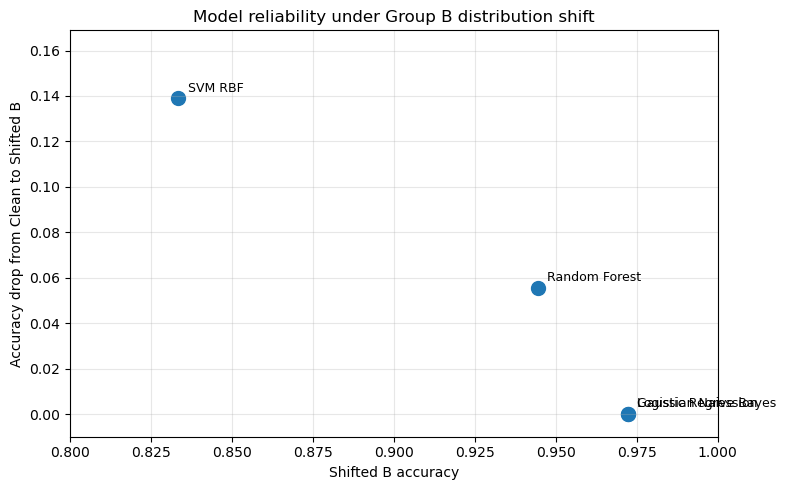

In [133]:
plt.figure(figsize=(8, 5))

plt.scatter(
    accuracy_results["shifted_B_accuracy"],
    accuracy_results["accuracy_drop"],
    s=100
)

for _, row in accuracy_results.iterrows():
    plt.text(
        row["shifted_B_accuracy"] + 0.003,
        row["accuracy_drop"] + 0.003,
        row["model"],
        fontsize=9
    )

plt.xlabel("Shifted B accuracy")
plt.ylabel("Accuracy drop from Clean to Shifted B")
plt.title("Model reliability under Group B distribution shift")

plt.xlim(0.80, 1.00)
plt.ylim(-0.01, max(accuracy_results["accuracy_drop"]) + 0.03)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This plot summarises the final model judgement. A reliable model should have high Shifted B accuracy and a low accuracy drop, so the strongest models are closest to the bottom-right of the plot. Logistic Regression and Gaussian Naïve Bayes are the most stable because they keep high Shifted B accuracy with no accuracy drop. Random Forest also performs well, but it loses some performance under the shift. SVM RBF is the least reliable because it has the largest accuracy drop and the lowest Shifted B accuracy.

### 5.2 Which model fails most gracefully

Among the models that did degrade, Random Forest fails most gracefully. It achieved the best Clean test accuracy of 1.000 and dropped only slightly to 0.944 on the Shifted B test set. Its accuracy drop was 0.056, which is much smaller than the SVM RBF drop of 0.139.

The confusion matrices show that Random Forest only made two mistakes on the Shifted B test set. It predicted one true Class 0 sample as Class 1 and one true Class 2 sample as Class 1. Class 1 itself stayed stable, with all true Class 1 samples being correctly identified. 

This means that Random Forest was affected by the shift, but its mistakes were few. It didn't collapse across multiple classes, and its class-wise F1-score drops were small compared to SVM RBF. Therefore, Random Forest is not the most stable model overall, but it is the best example of a model that degrades in a controlled way rather than failing sharply.

### 5.3 What happens when model assumptions are violated by degraded data

The SVM RBF model shows the clearest example of what happens when a model’s assumptions are violated by degraded or shifted data. SVM RBF depends strongly on distances and geometry in the scaled feature space. The Group B shift changed several feature values and moved many samples outside the training range. This changed where test samples appeared relative to the learned SVM decision boundary.

This produced a systematic failure pattern. SVM RBF dropped from 0.972 accuracy on the Clean test set to 0.833 on the Shifted B test set. The class-wise results showed that Class 0 was most affected, with a recall drop of 0.333 and an F1-score drop of 0.200. The difference in the confusion matrix showed that four real Class 0 samples were wrongly classified as Class 1 when the data was shifted. 

This means that the degraded data didn't just add random noise; it changed the structure of the feature space in a way that made the SVM move some Class 0 and Class 2 samples closer to the Class 1 decision region. This shows that when a model’s inductive bias is violated, performance may degrade in a class-specific and systematic way.

The same idea applies more generally. Logistic Regression assumes a linear decision structure, Gaussian Naïve Bayes assumes Gaussian class-conditional feature distributions and conditional independence, SVM assumes useful margin-based separation in feature space, and Random Forest assumes that learned feature-threshold splits remain useful. When shifted data breaks these assumptions, models may become unreliable even if they performed well on the Clean test set.

### 5.4 Real deployment mitigation strategies

In a real deployment, I would not rely only on Clean test performance. This assignment shows that a model can perform well on clean held-out data but behave differently when the input feature distribution changes.

First, I would monitor feature distributions in production. The main issue in this assignment was covariate shift in `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`. A deployed system should compare incoming feature values with the training distribution and alert when important features drift or move outside expected ranges.

Second, I would add data-quality checks for out-of-range values. The EDA showed that many Shifted B values fell outside the training range, especially for `nonflavanoid_phenols`, `alcohol`, and `color_intensity`. Samples with several out-of-range values could be flagged for review because the model is being asked to predict in unfamiliar regions of the feature space.

Third, I would monitor class-wise performance, not only overall accuracy. The SVM RBF model mainly failed on Class 0, which was often confused with Class 1. Therefore, I would track precision, recall, F1-score, and confusion matrices by class whenever labels become available.

Fourth, I would retrain or update the model if the shifted data represents a real and persistent change in data collection. For example, if a new measurement process or equipment caused the shift, the training data should be updated to include examples from the new distribution.

Finally, I would use confidence-based safeguards. If the model is uncertain or the input is far from the training distribution, the system could flag the prediction for manual review instead of treating it as fully reliable. This would help reduce the risk of systematic failures like the SVM RBF Class 0 to Class 1 confusion observed in this assignment.

### 5.5 Final judgement

Based on this experiment, I think Logistic Regression is the best choice if you want to make sure that the model works well on both the Clean and Shifted B evaluation sets. It kept the same accuracy on both test sets and is easy to understand. Gaussian Naïve Bayes was equally stable in terms of accuracy, but its stronger distributional assumptions make me slightly more cautious about relying on it under other types of shift.

Random Forest is also a strong candidate because it achieved the best Clean test performance and only degraded slightly under Shifted B. It failed more gracefully than SVM RBF, making only a small number of additional errors. However, the fact that it dropped from perfect Clean accuracy to lower shifted accuracy shows that high Clean test performance does not guarantee robustness.

SVM RBF was the least reliable model under this Group B shift. Although it performed well on the Clean test set, it had the largest accuracy drop and the strongest class-wise degradation. Its main failure was misclassifying true Class 0 samples as Class 1 under the shifted data.

The main conclusion is that model choice should not be based only on Clean test accuracy. For deployment, I would choose a model that combines strong performance with stable behaviour under distribution shift, supported by feature monitoring, out-of-range checks, class-wise performance monitoring, and retraining when drift becomes persistent.

## 6. Inductive Bias Stress Test

I selected SVM RBF because it was already the most sensitive model under the Group B shift. I designed a controlled perturbation that stretches selected feature values away from the training mean. This directly challenges the SVM’s distance-based inductive bias. I expected the model to lose accuracy and especially confuse samples whose shifted values move closer to the wrong decision region.

### 6.1 Selected model and inductive bias

I chose this model because the earlier analysis showed that it was the least robust under the Group B shift. Its accuracy dropped from 0.972 on the Clean test set to 0.833 on the Shifted B test set.

The SVM RBF model has a distance-based inductive bias. It relies on the geometry of the scaled feature space and tries to separate classes using a large-margin decision boundary. The RBF kernel is flexible, but it is also sensitive to where samples lie relative to the training data and support vectors.

Therefore, I designed a perturbation that deliberately changes the geometry of the Clean test set without changing the labels.

### 6.2 Designed perturbation

I perturb the Clean test set by stretching the shifted features away from their training-set means. The features I perturb are the same features identified in the EDA as affected by the Group B shift: `color_intensity`, `alcohol`, `proanthocyanins`, `hue`, and `nonflavanoid_phenols`.

The perturbation is defined as:

`x_perturbed = training_mean + scale_factor × (x_clean - training_mean)`

I use a scale factor of 2.5 to do this. This keeps the direction of each Clean test value relative to the training mean, but pushes it further away. The perturbation is deterministic, modifies input features only, does not change labels, and does not retrain the model.

### 6.3 Expected failure mode

Before running the experiment, I expect the SVM RBF model to lose performance on the perturbed Clean set. This is because the perturbation makes samples in the chosen feature dimensions move farther away from the training distribution.

Since the RBF SVM depends on distances in the scaled feature space, stretching these features should change how close test samples appear to the learned class regions. I expect some samples, especially those near the original decision boundary, to move closer to the wrong class region. Based on the earlier Group B results, I expect errors to increase mainly through samples being predicted as Class 1.

### 6.4 Applying the perturbation to the Clean set

In [135]:
selected_model_name = "SVM RBF"
selected_model = results[selected_model_name]["model"]

stress_features = [
    "color_intensity",
    "alcohol",
    "proanthocyanins",
    "hue",
    "nonflavanoid_phenols"
]

scale_factor = 2.5

X_test_stressed = X_test_clean.copy()

for feature in stress_features:
    train_mean = X_train[feature].mean()
    X_test_stressed[feature] = (
        train_mean + scale_factor * (X_test_clean[feature] - train_mean)
    )

X_test_stressed.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,15.792782,2.16,2.30,18.0,105.0,2.95,3.32,0.009789,3.549683,6.890528,1.701521,3.17,1510.0
1,11.817782,1.24,2.25,17.5,85.0,2.00,0.58,0.959789,0.724683,6.140528,0.451521,1.51,650.0
2,15.217782,1.90,2.80,19.4,107.0,2.95,2.97,0.384789,1.999683,3.765528,1.701521,3.40,915.0
3,9.442782,2.05,3.23,28.5,119.0,3.18,5.08,0.634789,2.274683,7.515528,0.901521,3.69,465.0
4,14.717782,1.25,1.92,18.0,94.0,2.10,1.79,0.259789,-0.575317,2.015528,1.651521,2.46,630.0


In [136]:
perturbation_summary = pd.DataFrame(index=stress_features)

perturbation_summary["train_mean"] = X_train[stress_features].mean()
perturbation_summary["clean_mean"] = X_test_clean[stress_features].mean()
perturbation_summary["stressed_mean"] = X_test_stressed[stress_features].mean()

perturbation_summary["clean_min"] = X_test_clean[stress_features].min()
perturbation_summary["clean_max"] = X_test_clean[stress_features].max()

perturbation_summary["stressed_min"] = X_test_stressed[stress_features].min()
perturbation_summary["stressed_max"] = X_test_stressed[stress_features].max()

perturbation_summary.round(3)

,train_mean,clean_mean,stressed_mean,clean_min,clean_max,stressed_min,stressed_max
color_intensity,4.990,5.328,5.836,2.15,10.68,-2.109,19.216
alcohol,12.971,13.116,13.332,11.56,14.38,9.443,16.493
proanthocyanins,1.600,1.554,1.485,0.41,2.96,-1.375,5.000
hue,0.949,0.991,1.054,0.60,1.45,0.077,2.202
nonflavanoid_phenols,0.360,0.369,0.381,0.17,0.66,-0.115,1.110


The perturbation successfully changed the selected input features while leaving the other features unchanged. The stressed feature ranges are much wider than the original Clean test ranges. For example, `color_intensity` changes from a Clean range of 2.15–10.68 to a stressed range of -2.109–19.216. `proanthocyanins` also becomes much wider, changing from 0.41–2.96 to -1.375–5.000.

The mean values do not change as dramatically as the minimum and maximum values because the perturbation stretches values around the training mean. This is expected from the formula:

`x_perturbed = training_mean + scale_factor × (x_clean - training_mean)`

This shows that the perturbation is not random noise; it is a controlled distortion of the feature space that moves Clean test samples further away from the training distribution in the chosen dimensions. The SVM RBF model uses distances in scaled feature space, so this change directly affects its inductive bias.

### 6.5 Quantitative evaluation

In [137]:
y_pred_clean_svm = results[selected_model_name]["y_pred_clean"]
y_pred_stressed = selected_model.predict(X_test_stressed)

clean_accuracy_svm = accuracy_score(y_test, y_pred_clean_svm)
stressed_accuracy_svm = accuracy_score(y_test, y_pred_stressed)

stress_results = pd.DataFrame({
    "evaluation_set": ["Clean test", "Perturbed Clean test"],
    "accuracy": [clean_accuracy_svm, stressed_accuracy_svm]
})

stress_results["accuracy_drop_from_clean"] = (
    clean_accuracy_svm - stress_results["accuracy"]
)

stress_results.round(3)

,evaluation_set,accuracy,accuracy_drop_from_clean
0,Clean test,0.972,0.000
1,Perturbed Clean test,0.611,0.361


The perturbation had a big effect on the already trained SVM RBF model. The accuracy on the clean test set was 0.972, but it dropped to 0.611 on the perturbed clean test set. This is a drop of 0.361 in accuracy.

This confirms that the designed perturbation successfully stressed the SVM RBF model. Since the model was not retrained and the labels were not changed, the performance drop is caused by changing the input feature geometry.

In [138]:
stress_report_clean = classification_report(
    y_test,
    y_pred_clean_svm,
    output_dict=True,
    zero_division=0
)

stress_report_perturbed = classification_report(
    y_test,
    y_pred_stressed,
    output_dict=True,
    zero_division=0
)

stress_metric_rows = []

for class_label in sorted(y_test.unique()):
    clean_metrics = stress_report_clean[str(class_label)]
    perturbed_metrics = stress_report_perturbed[str(class_label)]
    
    stress_metric_rows.append({
        "class": f"Class {class_label}",
        "clean_precision": clean_metrics["precision"],
        "perturbed_precision": perturbed_metrics["precision"],
        "clean_recall": clean_metrics["recall"],
        "perturbed_recall": perturbed_metrics["recall"],
        "clean_f1": clean_metrics["f1-score"],
        "perturbed_f1": perturbed_metrics["f1-score"],
        "recall_drop": clean_metrics["recall"] - perturbed_metrics["recall"],
        "f1_drop": clean_metrics["f1-score"] - perturbed_metrics["f1-score"]
    })

stress_class_metrics = pd.DataFrame(stress_metric_rows)
stress_class_metrics.round(3)

,class,clean_precision,perturbed_precision,clean_recall,perturbed_recall,clean_f1,perturbed_f1,recall_drop,f1_drop
0,Class 0,1.000,1.0,1.0,0.5,1.000,0.667,0.5,0.333
1,Class 1,0.933,0.5,1.0,1.0,0.966,0.667,0.0,0.299
2,Class 2,1.000,1.0,0.9,0.2,0.947,0.333,0.7,0.614


The stress test had different effects on different classes. Class 2 was the most affected: its recall dropped from 0.900 to 0.200, and its F1-score dropped from 0.947 to 0.333. Class 0 was also strongly affected, with recall dropping from 1.000 to 0.500 and F1-score dropping from 1.000 to 0.667.

Class 1 recall stayed at 1.000, which means that all true Class 1 samples were still correctly identified. However, Class 1 precision dropped from 0.933 to 0.500, which means that the model was more likely to predict Class 1 for samples that actually belonged to other classes.

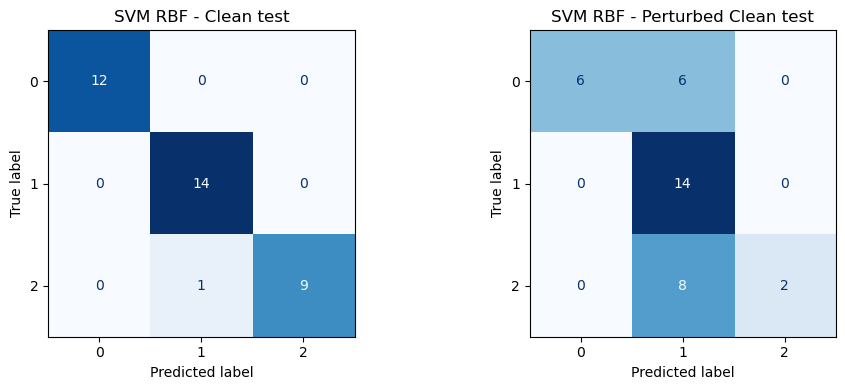

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_clean_svm,
    labels=class_labels,
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("SVM RBF - Clean test")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_stressed,
    labels=class_labels,
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)
axes[1].set_title("SVM RBF - Perturbed Clean test")

plt.tight_layout()
plt.show()

The confusion matrices explain the drop in performance. On the Clean test set, SVM RBF made only one error. On the perturbed Clean test set, it made many more errors.

The main failure pattern is that the model over-predicts Class 1. Six true Class 0 samples are misclassified as Class 1, and eight true Class 2 samples are also misclassified as Class 1. This is consistent with the expected failure mode: stretching the selected features changed the SVM feature-space geometry and moved many samples toward the Class 1 decision region.

This result is similar to the earlier Group B shift analysis, where SVM RBF also tended to misclassify shifted Class 0 and Class 2 samples as Class 1. The designed perturbation therefore successfully reproduces and amplifies the same type of failure.

### 6.6 Diagnosing the observed behaviour

In [140]:
clean_cm_stress = confusion_matrix(
    y_test,
    y_pred_clean_svm,
    labels=class_labels
)

stressed_cm = confusion_matrix(
    y_test,
    y_pred_stressed,
    labels=class_labels
)

stress_cm_difference = stressed_cm - clean_cm_stress

stress_cm_difference_table = pd.DataFrame(
    stress_cm_difference,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

stress_cm_difference_table

,Predicted 0,Predicted 1,Predicted 2
Actual 0,-6,6,0
Actual 1,0,0,0
Actual 2,0,7,-7


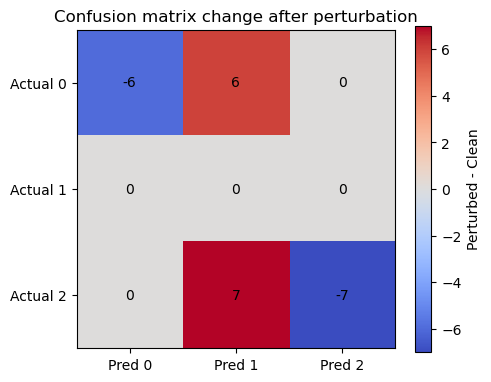

In [141]:
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(stress_cm_difference, cmap="coolwarm")

ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels([f"Pred {label}" for label in class_labels])
ax.set_yticklabels([f"Actual {label}" for label in class_labels])

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j, i, stress_cm_difference[i, j], ha="center", va="center")

plt.title("Confusion matrix change after perturbation")
plt.colorbar(im, label="Perturbed - Clean")
plt.tight_layout()
plt.show()

The confusion-matrix difference is calculated as:

`Perturbed Clean confusion matrix - Clean confusion matrix`

The table and heatmap show that the perturbation created a strong systematic error pattern. SVM RBF lost six correct Class 0 predictions, shown by `-6` in the `Actual 0, Predicted 0` cell. Those six samples moved into the `Actual 0, Predicted 1` cell, meaning they were misclassified as Class 1.

The same pattern appears even more strongly for Class 2. The model lost seven correct Class 2 predictions and gained seven additional `Actual 2 → Predicted 1` errors. This means the perturbation caused the SVM to over-predict Class 1 for samples that actually belonged to Class 0 or Class 2.

This directly supports the expected failure mode. By stretching selected features away from their training means, the perturbation changed the feature-space geometry used by the RBF kernel. Many samples were moved toward the Class 1 decision region, causing systematic class confusion rather than random errors.

In [142]:
outside_range_stress_rows = []

for feature in stress_features:
    train_min = X_train[feature].min()
    train_max = X_train[feature].max()
    
    clean_outside = (
        (X_test_clean[feature] < train_min) |
        (X_test_clean[feature] > train_max)
    ).sum()
    
    stressed_outside = (
        (X_test_stressed[feature] < train_min) |
        (X_test_stressed[feature] > train_max)
    ).sum()
    
    outside_range_stress_rows.append({
        "feature": feature,
        "clean_outside_train_range": clean_outside,
        "stressed_outside_train_range": stressed_outside
    })

outside_range_stress = pd.DataFrame(outside_range_stress_rows)
outside_range_stress

,feature,clean_outside_train_range,stressed_outside_train_range
0,color_intensity,0,14
1,alcohol,0,18
2,proanthocyanins,1,10
3,hue,0,10
4,nonflavanoid_phenols,1,21


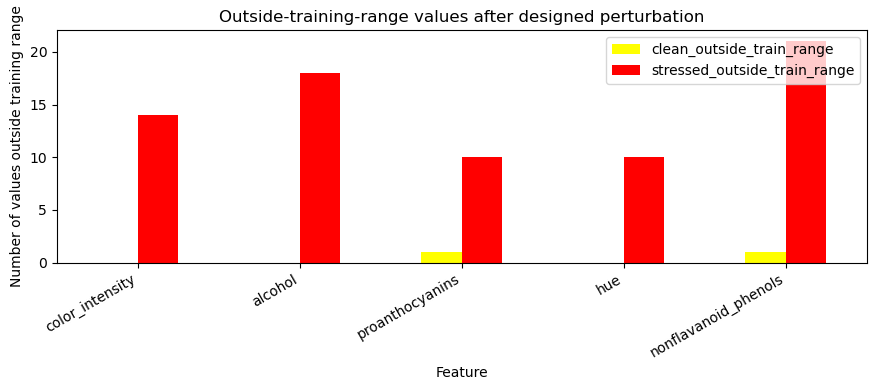

In [146]:
outside_range_stress.set_index("feature").plot(kind="bar", figsize=(9, 4), color=["yellow", "red"])

plt.title("Outside-training-range values after designed perturbation")
plt.xlabel("Feature")
plt.ylabel("Number of values outside training range")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The outside-training-range analysis confirms that the designed perturbation pushed many selected feature values beyond the training distribution. Compared with the original Clean test set, the perturbed set has many more out-of-range values for every stressed feature.

The largest increases are for `nonflavanoid_phenols`, with 21 stressed values outside the training range, `alcohol`, with 18, and `color_intensity`, with 14. `proanthocyanins` and `hue` also increase to 10 outside-range values each.

This confirms that the perturbation successfully created a controlled feature-space shift. The SVM RBF model depends on meaningful distances in the scaled training feature space, so pushing many values outside the training range makes its learned decision structure less reliable.

### 6.7 Stress test conclusion

This stress test deliberately challenged the SVM RBF model’s inductive bias by stretching selected features away from their training-set means. The perturbation was applied only to the Clean test inputs, the labels were not changed, and the model was not retrained.

The results confirm the expected failure mode. SVM RBF accuracy dropped from 0.972 on the Clean test set to 0.611 on the perturbed Clean test set, giving an accuracy drop of 0.361. This is a much larger drop than the one observed on the original Group B shifted test set.

The results by class show that Class 2 was the worst affected, with recall dropping from 0.900 to 0.200 and F1-score dropping from 0.947 to 0.333. Class 0 also got worse, with recall going down from 1.000 to 0.500. Class 1 recall stayed at 1.000, but its precision dropped because many Class 0 and Class 2 samples were incorrectly predicted as Class 1.

The difference in the confusion matrix shows that the perturbation caused a pattern of systematic failure. Six true Class 0 samples and seven true Class 2 samples became misclassified as Class 1. This shows that the perturbation did not just add random noise; it changed the SVM’s feature-space geometry in a way that moved samples toward the Class 1 decision region.

Overall, the stress test successfully demonstrates how violating a model’s inductive bias can damage generalisation. The RBF SVM relies on distances and local structure in the scaled feature space. When selected features are deliberately pushed away from the training distribution, the model becomes much less reliable. This supports the broader conclusion of the assignment: models should be evaluated not only on clean held-out data, but also under shifts that test whether their assumptions remain valid.

## 7. AI integrity statement

I only used generative AI tools in a clear and limited way for this assignment. AI was used to support initial brainstorming of the notebook structure, explain course concepts, suggest possible approaches for the inductive bias stress test, help debug Python errors, and improve the clarity and grammar of some Markdown explanations.

I wrote and ran the code in my notebook and checked the outputs myself. The model selection, EDA interpretation, failure-mode analysis, stress-test design, class-wise result interpretation, and final conclusions were based on my own engagement with the data, results, and course material.

I am totally accountable for the analysis, interpretation, and findings made in this notebook, and I am aware of the methodologies employed and every part of my proposal may be explained and defended by me. 

## References

- https://scikit-learn.org/stable/modules/svm.html
- https://3d.bk.tudelft.nl/courses/geo5017/slides/05_slides_SVM-lab.pdf
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- https://tallinzen.net/media/papers/lovering_jha_linzen_pavlick_2021_iclr.pdf
- https://machinelearningplus.com/machine-learning/exploratory-data-analysis-eda/
- https://docs.aws.amazon.com/sagemaker/latest/dg/model-monitor-create-baseline.html
- https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- https://machine-learning-made-simple.medium.com/an-introduction-to-adversarial-perturbation-5e6c61d84b71
- https://medium.com/@slavadubrov/understanding-machine-learning-robustness-why-it-matters-and-how-it-affects-your-models-5e2cb5838dab